In [89]:
data_path_cc<-'/mnt/cold2/snaketree/prj/PPH/local/share/data/cc_data/filtered_annotated_saver_ribomito_CRC0542_NT72h_1_cellCycle.csv'
data_path_hes<-'/mnt/cold2/snaketree/prj/PPH/dataset/Kmeans/popular_genes_datasets/CRC0542_NT72h_1_log2cpm.csv'

In [90]:
data_cc<-read.table(data_path_cc,header = FALSE,row.names = 1,stringsAsFactors = FALSE,sep = ',')
colnames(data_cc)<-'cc'
data_hes<-read.table(data_path_hes,header = TRUE,row.names = 1,stringsAsFactors = FALSE,sep = ',')
data<-merge(data_cc, data_hes, by = "row.names")
row.names(data)<-data$Row.names
data$Row.names<-NULL

In [91]:
library(dplyr)
library(ggplot2)
library(rlang)

plot_cc_by_gene_quantiles <- function(df,
                                      gene = "HES1",
                                      cc_col = "cc",
                                      nq = 4,
                                      cc_levels = c("G1","S","G2M"),
                                      box_nudge = 0.45) {
  stopifnot(gene %in% names(df), cc_col %in% names(df))

  df2 <- df %>%
    filter(!is.na(.data[[gene]]), !is.na(.data[[cc_col]])) %>%
    mutate(H_q = ntile(.data[[gene]], nq))

  if (!is.null(cc_levels)) {
    df2 <- df2 %>%
      mutate(!!cc_col := factor(.data[[cc_col]], levels = cc_levels))
  }

  counts <- df2 %>% count(H_q, !!sym(cc_col), name = "n")
  max_count <- max(counts$n)
  scale_factor <- max_count / max(df2[[gene]], na.rm = TRUE)

  ggplot() +
    geom_col(
      data = counts,
      aes(x = factor(H_q), y = n, fill = !!sym(cc_col)),
      position = position_dodge(width = 0.65), width = 0.55
    ) +
    geom_boxplot(
      data = df2,
      aes(x = factor(H_q), y = .data[[gene]] * scale_factor),
      width = 0.22, fill = "grey30", alpha = 0.25, outlier.alpha = 0.2,
      position = position_nudge(x = box_nudge)
    ) +
    scale_y_continuous(
      name = "N cells",
      sec.axis = sec_axis(~ . / scale_factor, name = paste("Expression ", gene))
    ) +
    labs(x = paste( gene,"quantile"), fill = "Cell Cycle phase") +
    theme_classic() +
    coord_cartesian(clip = "off") +
    theme(legend.position = "none",
      # linee e tacche asse Y sinistro
      axis.line.y = element_line(color = "black"),
      axis.ticks.y = element_line(color = "black"),
      # linee e tacche asse Y destro (secondario)
      axis.line.y.right = element_line(color = "black"),
      axis.ticks.y.right = element_line(color = "black"),
      # un po' di margine a destra per evitare il taglio delle etichette
      plot.margin = margin(5.5, 12, 5.5, 5.5)
    )
}





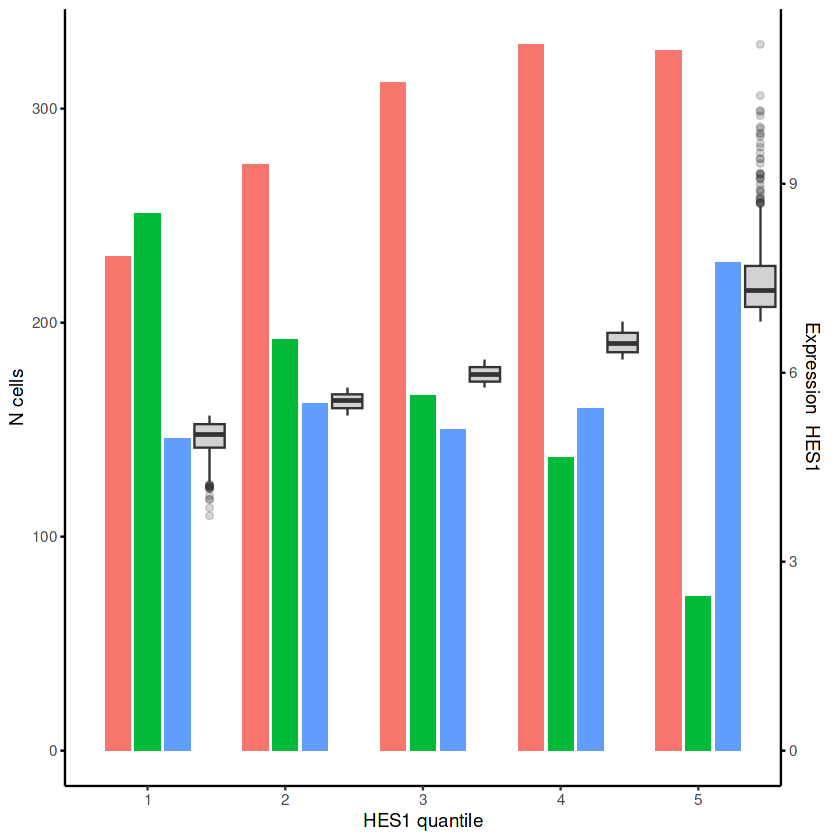

In [94]:

plot_cc_by_gene_quantiles(data, gene = "HES1", nq = 5, cc_levels = c("G1","S","G2M"))


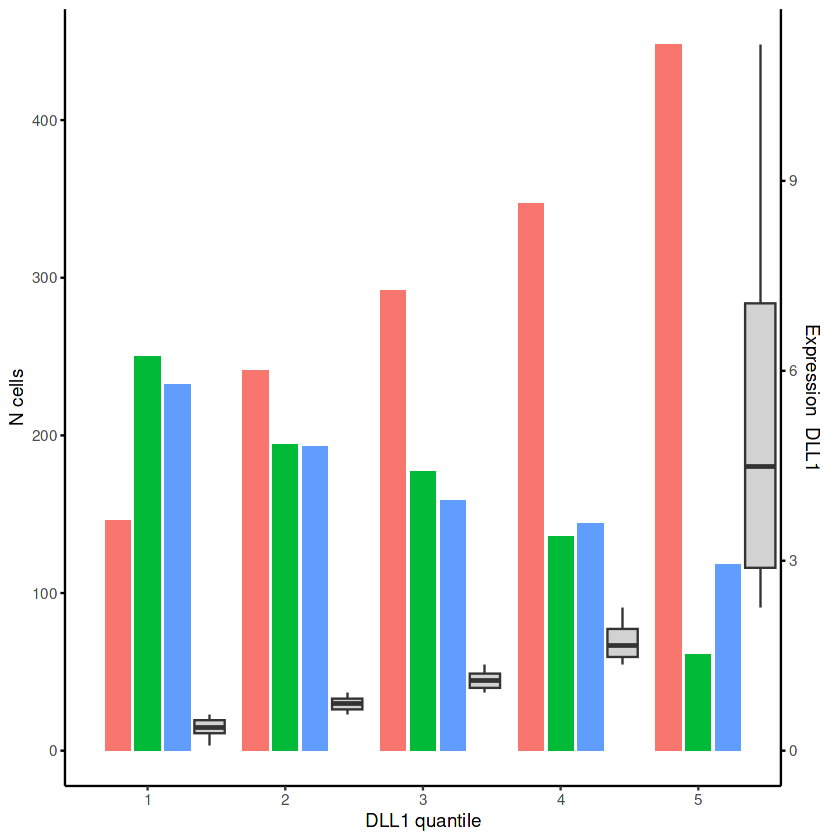

In [95]:
plot_cc_by_gene_quantiles(data, gene = "DLL1", nq = 5, cc_levels = c("G1","S","G2M"))